# Data Mining Project  
**Nicole Mei – Spring 2025**

---

## Project Overview

### Objective  
This project investigates how student habits affect academic performance.

### Dataset  
**Title**: *Student Habits vs Academic Performance*  
**Source**: Kaggle.com


## Libraries 

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from sklearn.metrics import classification_report, confusion_matrix



plt.rcParams['figure.dpi'] = 100


## Import the data
### Drop Student_ID (non-informative)

In [2]:
df = pd.read_csv("student_habits_performance.csv", na_values=[], keep_default_na=False)
if 'student_id' in df.columns:
    df.drop(columns='student_id', inplace=True)

## Understanding the data
### Shape

In [3]:
print("Training data shape:", df.shape)

rows, columns = df.shape
print(f"The data has {columns} attributes and {rows} rows.")

Training data shape: (1000, 15)
The data has 15 attributes and 1000 rows.


## Overview of the Attributes and Their Values in the Data

The table below shows the first five records in the dataset. Each row represents one student and each column represents a habit or factor potentially affecting academic performance, with the overall exam score as the final column.



In [4]:
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Variable Descriptions

| **Variable Name**             | **Description**                                                                 |
|------------------------------|----------------------------------------------------------------------------------|
| `age`                        | Student’s age                                                                   |
| `gender`                     | Student’s gender (`Male`, `Female`)                                             |
| `study_hours_per_day`        | Number of hours spent studying per day                                          |
| `social_media_hours`         | Time spent daily on social media platforms                                      |
| `netflix_hours`              | Hours spent watching Netflix per day                                            |
| `part_time_job`              | Whether the student has a part-time job (`Yes`/`No`)                            |
| `attendance_percentage`      | Percentage of class attendance                                                  |
| `sleep_hours`                | Average sleep hours per night                                                   |
| `diet_quality`               | Self-reported diet quality (`Poor`, `Average`, `Good`)                          |
| `exercise_frequency`         | Number of days per week the student exercises                                   |
| `parental_education_level`   | Highest education level attained by parents (`None`, `HS`, `Bachelor`, `Master`)|
| `internet_quality`           | Quality of internet connection at home (`Good`, `Average`, `Poor`)              |
| `mental_health_rating`       | Student’s self-rated mental health (1–10)                                       |
| `extracurricular_participation` | Whether the student participates in extracurriculars (`Yes`/`No`)         |
| `exam_score`                 | Final exam score (target variable, continuous 0–100)                            |
| `score_label`                | Binned version of `exam_score`: `Low`, `Medium`, `High`                         |


## Attribute Strcuture

In [5]:
df.info()

print("\n" + "-"*50 + "\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

### Observations:

- The dataset contains **1000 entries** (rows) and **16 attributes** (columns).
- All entries are complete and there are **no missing values**.
- **Attribute types:**
  - Numerical (int/float): `age`, `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `attendance_percentage`, `sleep_hours`, `exercise_frequency`, `mental_health_rating`, `exam_score`
  - Categorical (object/string): `gender`, `part_time_job`, `diet_quality`, `parental_education_level`, `internet_quality`, `extracurricular_participation`
- The target variable is **`exam_score`**


# Data Exploration 

## Do students who study more tend to score higher?

### 1.) Study Hours vs. Exam Score

Average Exam Score by Study Hours:

study_bin
<1     39.225641
1–2    48.193617
2–4    65.135685
4–6    81.277711
6–8    97.292157
Name: exam_score, dtype: float64


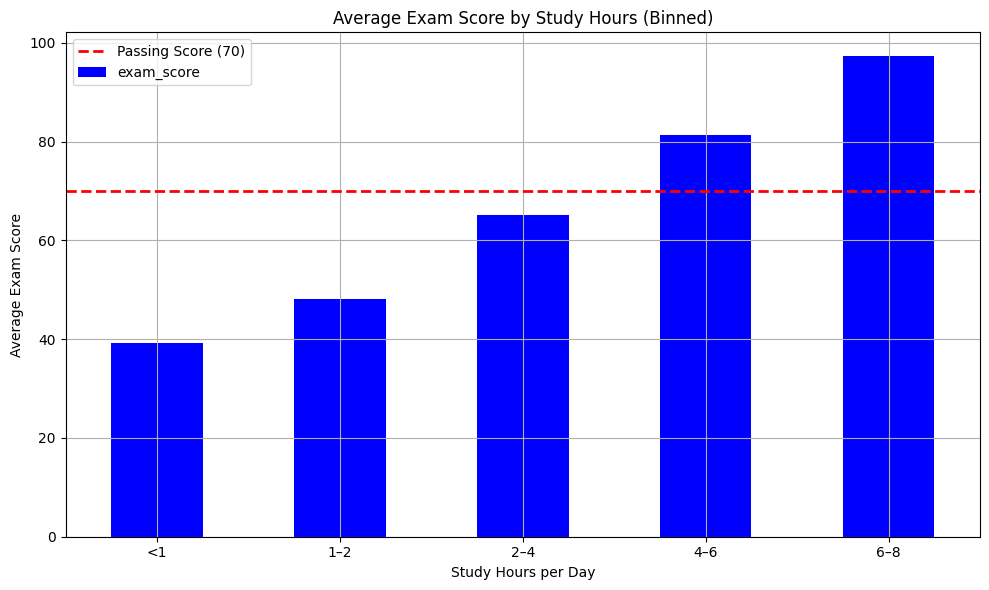

<Figure size 640x480 with 0 Axes>

In [6]:
bins = [0, 1, 2, 4, 6, 8]
labels = ["<1", "1–2", "2–4", "4–6", "6–8"]

df['study_bin'] = pd.cut(df['study_hours_per_day'], bins=bins, labels=labels, right=False)

study_score = df.groupby('study_bin', observed=False)['exam_score'].mean()

study_score = study_score.reindex(labels)

print("Average Exam Score by Study Hours:\n")
print(study_score)

ax = study_score.plot(kind='bar', figsize=(10, 6), legend=False, color='blue')
ax.set_title('Average Exam Score by Study Hours (Binned)')
ax.set_ylabel('Average Exam Score')
ax.set_xlabel('Study Hours per Day')
ax.set_xticklabels(labels, rotation=0)
ax.grid(True)
# hypothetical passing score line of 70
plt.axhline(y=70, color='red', linestyle='--', linewidth=2, label='Passing Score (70)')

plt.legend()

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()




## Observation: 
The Probability of exam scores is directly correlated to the amount of studying hours done per day
- The students who studied less than 1 hour scored the lowest average exam score
- The students who studied 6-8 hours scored the highest average exam score
- The average score between those who studied 2-4 hours vs. 4-6 hours is the bridge for a passing score (Assuming 70 is the passing score)

### 2.) Does sleep & exercise frequency affect exam scores

Average Exam Score by Sleep Hours:

sleep_bin
<5      65.01
5–6.5   68.83
6.5–8   71.58
8–10    71.43

--------------------------------------------------

Average Exam Score by Exercise Frequency:

exercise_bin
Rarely (0–1)       66.09
Sometimes (2–3)    69.30
Often (4–5)        70.83
Very Often (6–7)   74.57


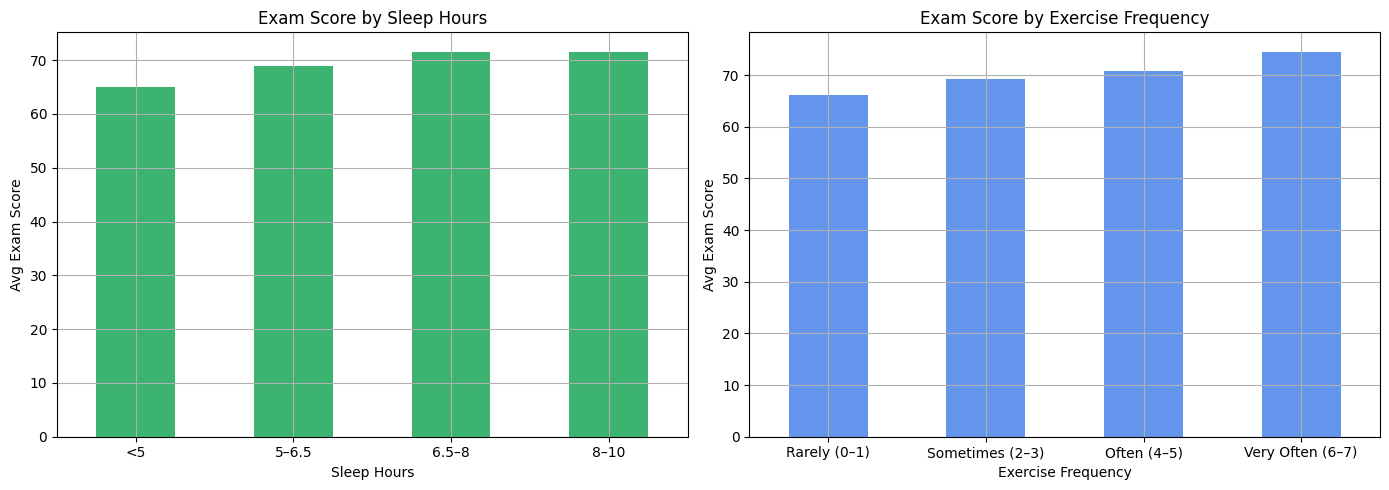

In [7]:
import matplotlib.pyplot as plt

df['sleep_bin'] = pd.cut(df['sleep_hours'],
                         bins=[0, 5, 6.5, 8, 10],
                         labels=["<5", "5–6.5", "6.5–8", "8–10"])
sleep_score = df.groupby('sleep_bin', observed=False)['exam_score'].mean()
ordered_sleep_bins = ["<5", "5–6.5", "6.5–8", "8–10"]
sleep_score = sleep_score.reindex(ordered_sleep_bins)


df['exercise_bin'] = pd.cut(df['exercise_frequency'],
                            bins=[-1, 1, 3, 5, 7],
                            labels=["Rarely (0–1)", "Sometimes (2–3)", "Often (4–5)", "Very Often (6–7)"])
exercise_score = df.groupby('exercise_bin', observed=False)['exam_score'].mean()
ordered_ex_bins = ["Rarely (0–1)", "Sometimes (2–3)", "Often (4–5)", "Very Often (6–7)"]
exercise_score = exercise_score.reindex(ordered_ex_bins)

print("Average Exam Score by Sleep Hours:\n")
print(sleep_score.to_string(float_format="{:.2f}".format))

print("\n" + "-"*50 + "\n")

print("Average Exam Score by Exercise Frequency:\n")
print(exercise_score.to_string(float_format="{:.2f}".format))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sleep plot
sleep_score.plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title("Exam Score by Sleep Hours")
axes[0].set_xlabel("Sleep Hours")
axes[0].set_ylabel("Avg Exam Score")
axes[0].set_xticklabels(ordered_sleep_bins, rotation=0)
axes[0].grid(True)

# Exercise plot
exercise_score.plot(kind='bar', ax=axes[1], color='cornflowerblue')
axes[1].set_title("Exam Score by Exercise Frequency")
axes[1].set_xlabel("Exercise Frequency")
axes[1].set_ylabel("Avg Exam Score")
axes[1].set_xticklabels(ordered_ex_bins, rotation=0)
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Observation:

- **Sleep Hours:**
  - Students who sleep between **6.5 to 8 hours** have the highest average exam scores (71.58).
  - There's a noticeable increase in performance from <5 hours (65.01) to 6.5–8 hours, suggesting that adequate sleep improves academic outcomes.
  - Sleeping more than 8 hours (8–10) maintains high performance but shows a slight dip, indicating that oversleeping is also detrimental to exam performance.

- **Exercise Frequency:**
  - Academic performance improves consistently with increased exercise frequency.
  - Students who exercise **Very Often (6–7 days/week)** score highest on average (74.57), while those who **rarely exercise** (0–1 days) score the lowest (66.09).
  - This strong positive trend suggests that **regular physical activity is strongly associated with higher academic performance**.

In summary, students who maintain **healthy sleep routines (6.5-8hrs) and engage in consistent exercise (frequency: 6-7)** tend to perform better academically. These lifestyle factors may contribute to better focus, energy, and mental health.


## 3.) Do Age and Sex Affect Academic Outcomes? 

Average Exam Score by Gender:

gender
Female    69.741372
Male      69.368344
Other     70.647619
Name: exam_score, dtype: float64


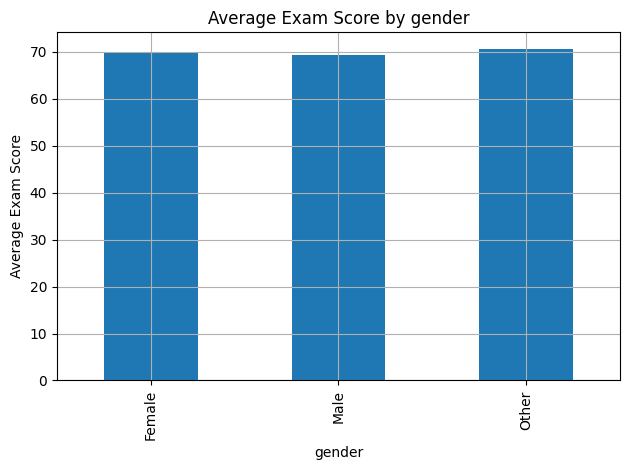

Average Exam Score by Age Group:

age_bin
17–18    70.342857
19–20    69.639565
21–22    68.823985
23–24    69.883880
Name: exam_score, dtype: float64


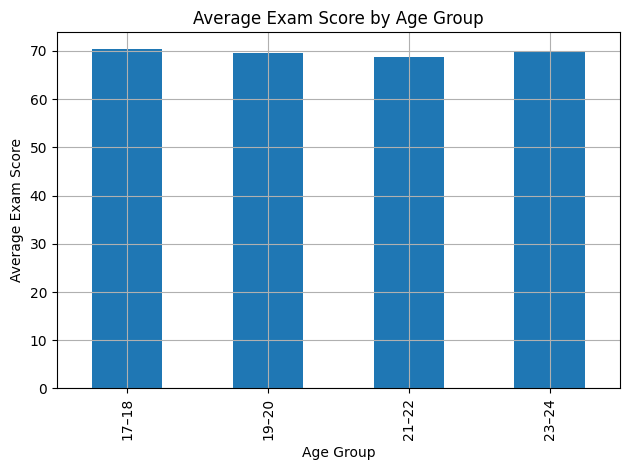

In [8]:
#gender
gender_means= df.groupby('gender')['exam_score'].mean()
print("Average Exam Score by Gender:\n")
print(gender_means)

df.groupby('gender')['exam_score'].mean().plot(kind='bar', title='Average Exam Score by gender')
plt.ylabel('Average Exam Score')
plt.xlabel('gender')
plt.grid(True)
plt.tight_layout()
plt.show()

# age 
df['age_bin'] = pd.cut(df['age'], bins=[16, 18, 20, 22, 25], labels=['17–18', '19–20', '21–22', '23–24'], right=False)

age_means = df.groupby('age_bin', observed=True)['exam_score'].mean()


print("Average Exam Score by Age Group:\n")
print(age_means)

df.groupby('age_bin', observed=True)['exam_score'].mean().plot(kind='bar', title='Average Exam Score by Age Group')
plt.ylabel('Average Exam Score')
plt.xlabel('Age Group')
plt.grid(True)
plt.tight_layout()
plt.show()



## Observation: 

These small differences suggest that demographic factors in this dataset do not strongly correlate with exam success, highlighting that individual habits and lifestyle choices are more impactful predictors of academic performance.

In contrast, average exam scores across gender categories were relatively the same

Likewise, performance by age group remained fairly stable, with a slight dip around ages 21–22 and a small increase at 23–24


## 4.) Does Social Media Usage Affect Exam Scores

Average Exam Score by Social Media Usage:
social_media_bin
Low (0–2)       73.196923
Medium (2–4)    68.613523
High (4+)       64.174336
Name: exam_score, dtype: float64

Average Exam Score by Netflix Usage:
netflix_bin
Low (0–2)       71.756642
Medium (2–4)    67.087007
High (4+)       66.477778
Name: exam_score, dtype: float64


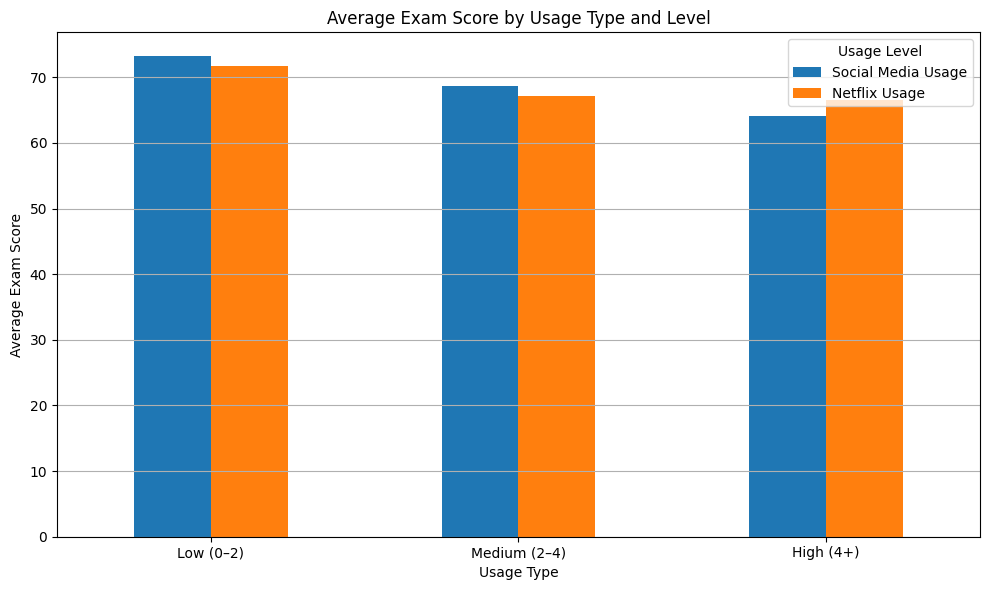

In [27]:
bins_social = [0, 2, 4, 8]
labels_social = ['Low (0–2)', 'Medium (2–4)', 'High (4+)']
df['social_media_bin'] = pd.cut(df['social_media_hours'], bins=bins_social, labels=labels_social, right=False)

bins_netflix = [0, 2, 4, 8]
labels_netflix = ['Low (0–2)', 'Medium (2–4)', 'High (4+)']
df['netflix_bin'] = pd.cut(df['netflix_hours'], bins=bins_netflix, labels=labels_netflix, right=False)

print("Average Exam Score by Social Media Usage:")
print(df.groupby('social_media_bin', observed=True)['exam_score'].mean())

print("\nAverage Exam Score by Netflix Usage:")
print(df.groupby('netflix_bin', observed=True)['exam_score'].mean())

social_scores = df.groupby('social_media_bin', observed=True)['exam_score'].mean()
netflix_scores = df.groupby('netflix_bin', observed=True)['exam_score'].mean()

df_combined = pd.DataFrame({
    'Social Media Usage': social_scores,
    'Netflix Usage': netflix_scores
}).T

df_combined = df_combined.T

ax = df_combined.plot(kind='bar', figsize=(10, 6), rot=0)
ax.set_title('Average Exam Score by Usage Type and Level')
ax.set_xlabel('Usage Type')
ax.set_ylabel('Average Exam Score')
ax.legend(title='Usage Level')
ax.grid(axis='y')
plt.tight_layout()
plt.show()


## Observation:

**Excessive screen time, whether on social media or streaming platforms, may negatively impact academic performance.**

The data shows a clear downward trend in performance as usage increases for both platforms.

- Students with low social media usage (0–2 hours/day) scored the highest on average.
- Students with high usage (4+ hours/day) had the lowest average exam scores among all categories.
- Students who watched less than 2 hours/day tended to perform better on exams compared to those with higher usage.


# EDA

## Class Distrubution (Pass/Fail)

Text(0, 0.5, 'Count')

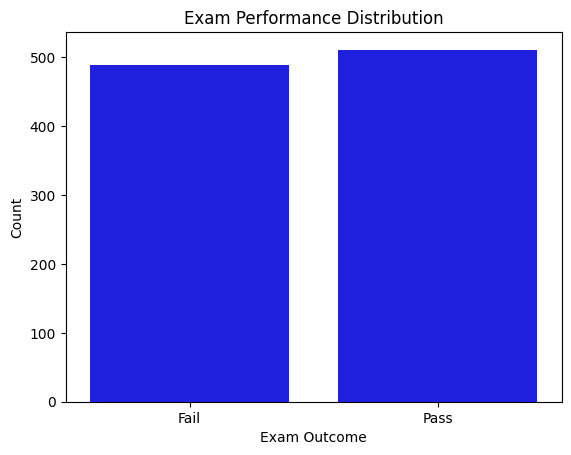

In [10]:
df['pass_fail'] = df['exam_score'].apply(lambda x: 'Pass' if x >= 70 else 'Fail')
sns.countplot(x='pass_fail', data=df, color='blue', order=['Fail', 'Pass'])
plt.title('Exam Performance Distribution')
plt.xlabel('Exam Outcome')
plt.ylabel('Count')

## Exam Score vs. Key Negative Behavior

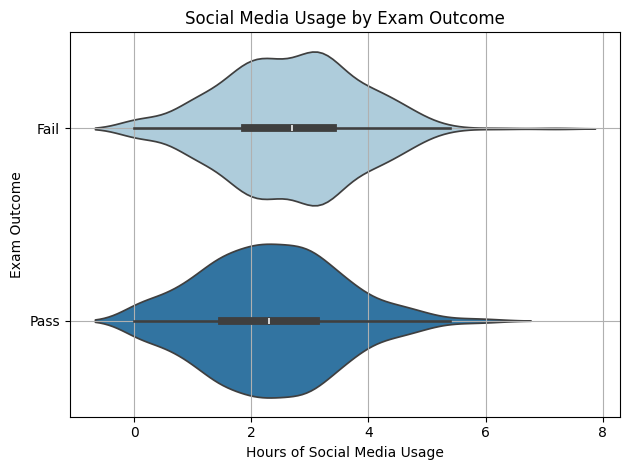

In [11]:
sns.violinplot(x='social_media_hours', y='pass_fail', data=df, hue= 'pass_fail', palette='Paired', legend= False)
plt.title('Social Media Usage by Exam Outcome')
plt.xlabel('Hours of Social Media Usage')
plt.ylabel('Exam Outcome')
plt.grid(True)
plt.tight_layout()
plt.show()

## Exam Score vs. Key Positive Behavior

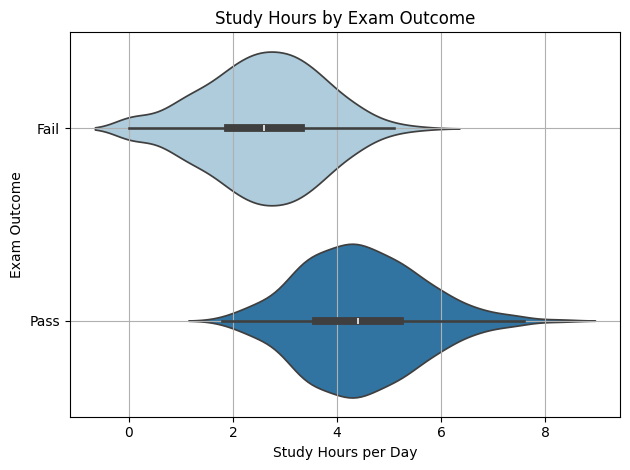

In [12]:
sns.violinplot(x='study_hours_per_day', y='pass_fail', data=df, hue='pass_fail', palette='Paired',legend=False)
plt.title('Study Hours by Exam Outcome')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Outcome')
plt.grid(True)
plt.tight_layout()
plt.show()

## EDA Observations

### Class Distribution (Pass vs. Fail)

The dataset shows a fairly balanced class distribution, with 511 students passing and 489 failing based on an exam score threshold of 70. This near-even split provides a strong foundation for comparative analysis across student behaviors.

### Exam Score vs. Key Negative Behavior: Social Media Usage

A clear difference is observed: students who failed tend to spend more time on social media daily, with usage frequently extending beyond 4 hours. In contrast, students who passed typically used social media less, clustering around 1.5 to 2.5 hours per day. 

### EDA: Exam Score vs. Key Positive Behavior (Study Hours)

Students who passed their exams tend to study more hours per day, with the highest density around 3.5 to 5 hours. In contrast, students who failed are more concentrated in the 1.5 to 3 hour range and rarely study beyond 4 hours.

# Correlation Matrix

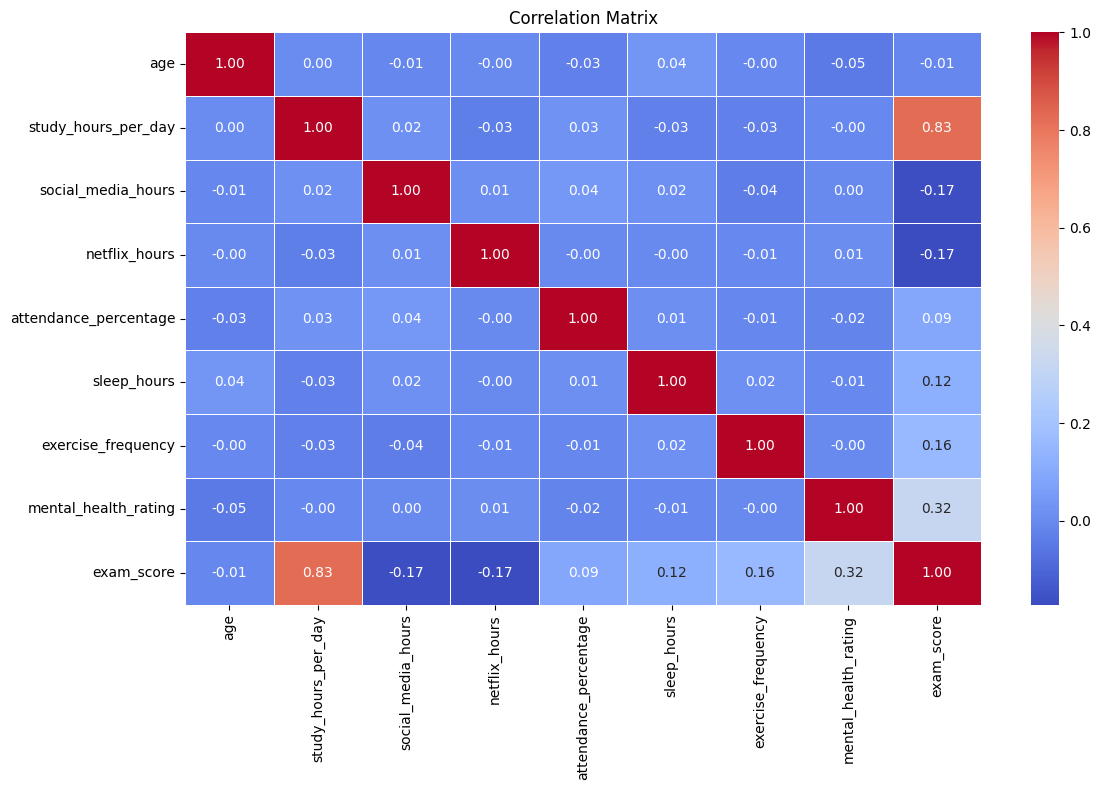

In [13]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8)) 

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Correlation Matrix Observations

The correlation matrix reveals that study hours per day is the most strongly correlated variable with exam score (r = 0.83), indicating that more study time is strongly associated with better academic performance. 

In contrast, both social media and Netflix hours show moderate negative correlations (r = -0.17), suggesting that excessive screen time may be detrimental to exam outcomes.

Well-being factors such as mental health rating (r = 0.32), exercise frequency (r = 0.16), and sleep hours (r = 0.12) also show positive correlations with exam performance, though to a lesser extent. 

Age and attendance percentage appear to have minimal influence on exam scores.


# K-Means Clustering

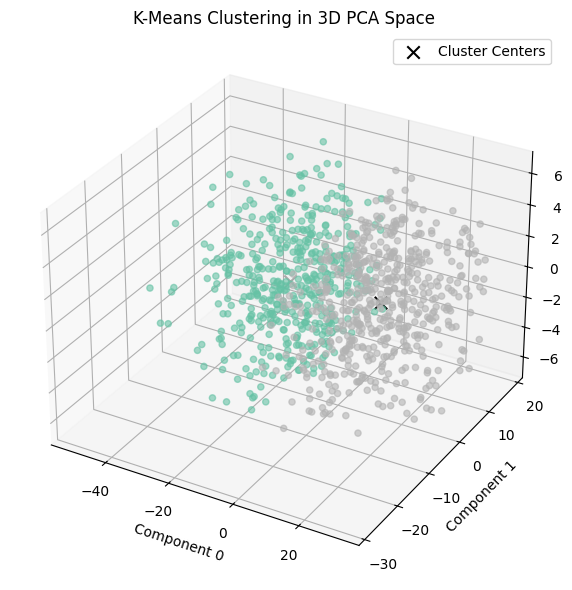

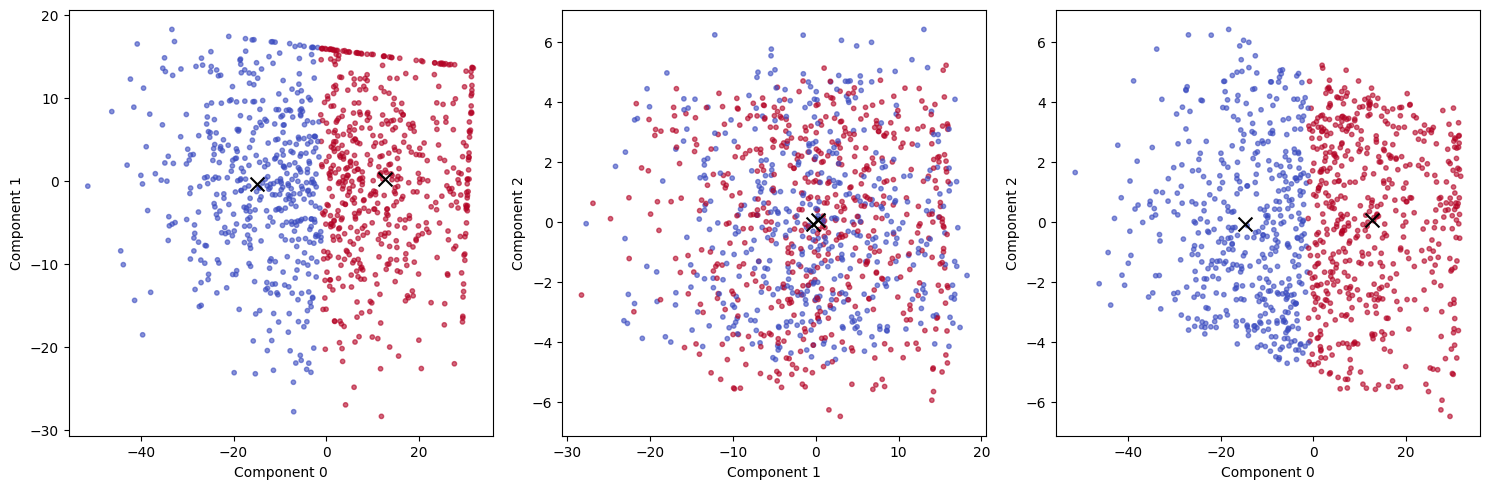

In [28]:
X = df.select_dtypes(include='number')

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca_3d)
centers = kmeans.cluster_centers_

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=clusters, cmap='Set2', s=20, alpha=0.6)
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='black', s=80, marker='x', label='Cluster Centers')
ax.set_title("K-Means Clustering in 3D PCA Space")
ax.set_xlabel("Component 0")
ax.set_ylabel("Component 1")
ax.set_zlabel("Component 2")
ax.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)
centers = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
components = [(0, 1), (1, 2), (0, 2)]

for idx, (i, j) in enumerate(components):
    axes[idx].scatter(X_pca[:, i], X_pca[:, j], c=labels, cmap='coolwarm', s=10, alpha=0.6)
    axes[idx].scatter(centers[:, i], centers[:, j], c='black', marker='x', s=100)
    axes[idx].set_xlabel(f'Component {i}')
    axes[idx].set_ylabel(f'Component {j}')

plt.tight_layout()
plt.show()

### K-Means Clustering Results

Using PCA to reduce the dataset to three principal components, K-Means clustering separated students into two distinct groups. 

The 3D scatter plot (visualized as three 2D projections) shows a clear separation between the clusters along Component 0, indicating that this principal component captures the most variance related to clustering. The centroids, marked by black Xs, are located in dense regions of each group, reflecting strong intra-cluster similarity.

While Components 1 and 2 show more overlap, the distinct split in Component 0 suggests that certain behavioral features may be the key drivers of the natural clustering. 


Cluster Summary Statistics:

         study_hours_per_day  sleep_hours  mental_health_rating  \
cluster                                                           
0                   3.333656     6.528046              5.410058   
1                   3.781781     6.408075              5.467909   

         social_media_hours  netflix_hours  exercise_frequency  exam_score  
cluster                                                                     
0                  2.352418       1.902901            4.709865   70.090716  
1                  2.669358       1.730642            1.256729   69.077847  


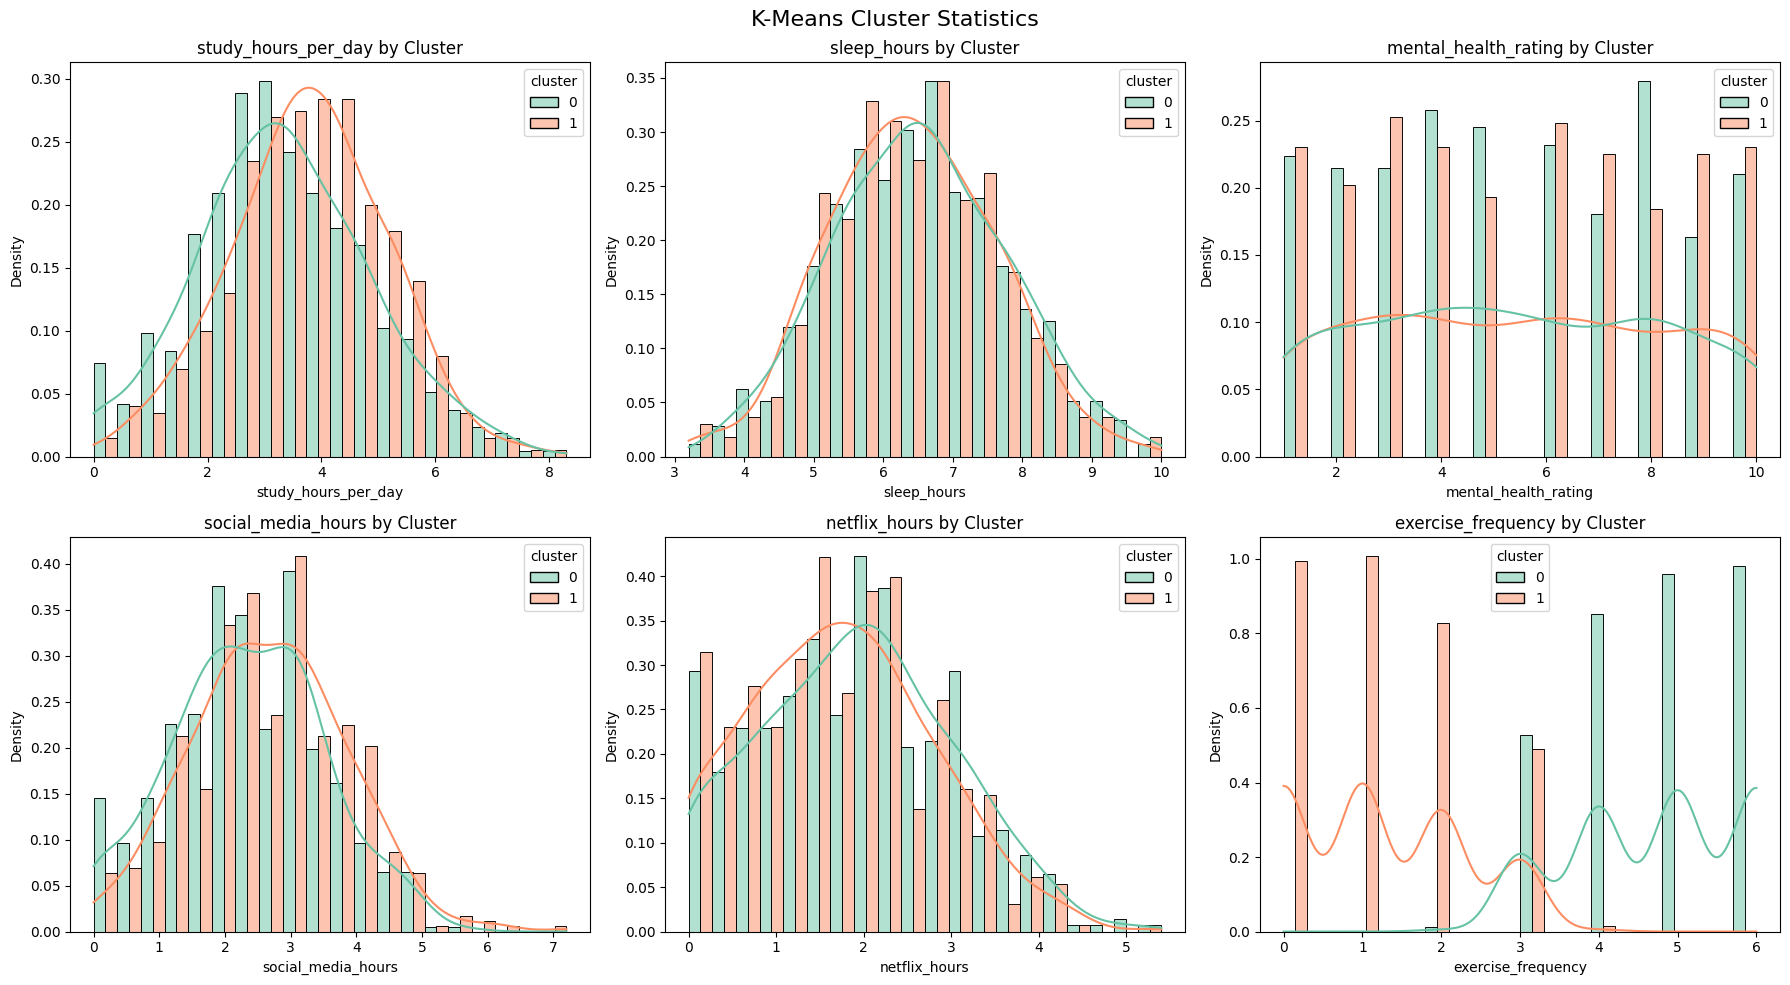

In [29]:
features_to_plot = ['study_hours_per_day', 'sleep_hours', 'mental_health_rating', 
                    'social_media_hours', 'netflix_hours', 'exercise_frequency']

X = df[features_to_plot]  


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


df_clustered = df.copy()
df_clustered['cluster'] = clusters

# for consistent reporting
df_clustered.to_csv("final_kmeans_clusters.csv", index=False)

cluster_stats = df_clustered.groupby('cluster')[features_to_plot + ['exam_score']].mean()
print("Cluster Summary Statistics:\n")
print(cluster_stats)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    sns.histplot(
        data=df_clustered,
        x=feature,
        hue='cluster',
        ax=axes[idx],
        bins=20,
        kde=True,
        palette='Set2',
        multiple='dodge',
        stat='density',
        common_norm=False
    )
    axes[idx].set_title(f'{feature} by Cluster')

    handles, labels = axes[idx].get_legend_handles_labels()
    if handles:
        axes[idx].legend(handles=handles, labels=labels, title='Cluster')

plt.suptitle("K-Means Cluster Statistics", fontsize=16)
plt.tight_layout()
plt.show()

### K-Means Cluster Statistics Results

K-Means clustering identified two distinct student behavior profiles based on six key lifestyle features:

- **Cluster 0** includes students who exercise more regularly and spend more time on social media and Netflix. Interestingly, despite slightly lower study hours and mental health ratings, they report slightly higher exam scores. This group may benefit from balancing leisure and productivity in a way that supports academic performance.

- **Cluster 1** includes students who study slightly more and report better mental health but engage in less physical activity. While their exam scores are only slightly lower, this group's routine appears more academically focused but less physically active.

These results highlight that effective academic performance can stem from different behavioral patterns. While study time and mental health remain important, the interaction between physical activity and screen time might play a more complex role than previously assumed.


# Hierarchical Clustering with Dendrogram

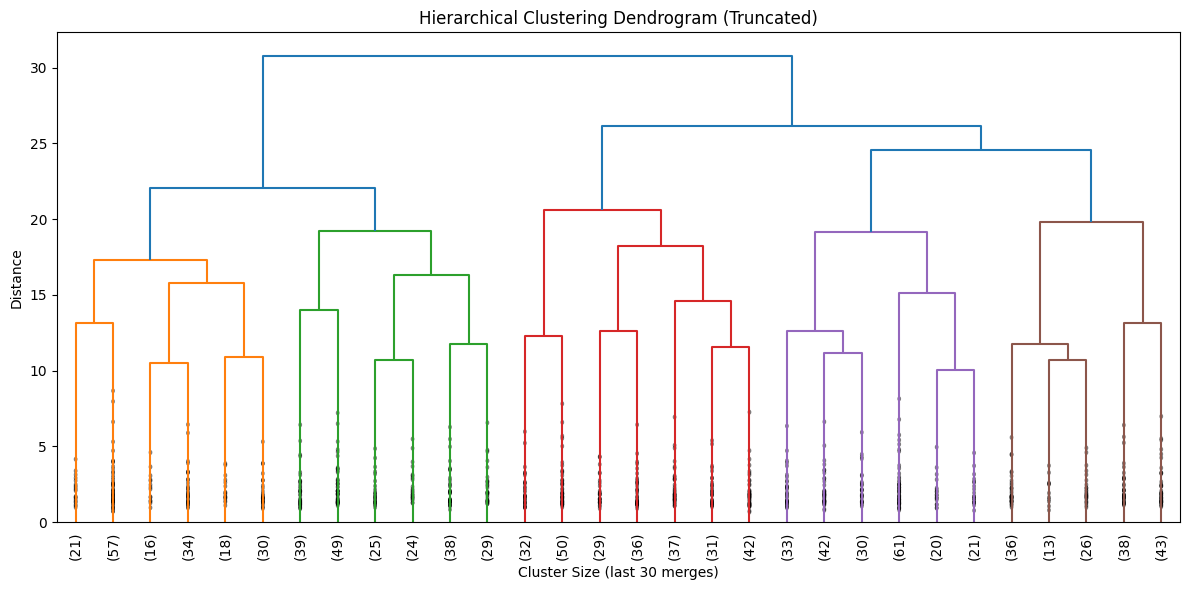

In [16]:
X = df.drop(columns=['exam_score'], errors='ignore').select_dtypes(include='number')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method='ward') 

plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp',  
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size (last 30 merges)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### Hierarchical Clustering Results

The dendrogram from hierarchical clustering illustrates the step-by-step grouping of students based on their behavioral data. Each branch merge represents a point at which two clusters were combined, with the vertical height indicating the dissimilarity between them.

- Several distinct groupings emerged before larger cluster merges occurred, suggesting that the data naturally forms **approximately 4–6 major clusters**. 


# Data Mining Algorithms (Modeling)

### Split the data

In [17]:
from sklearn.model_selection import train_test_split

X = df[[
    'study_hours_per_day', 'sleep_hours', 'social_media_hours', 'netflix_hours',
    'exercise_frequency', 'mental_health_rating'
]]
y = df['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(700, 6) (300, 6) (700,) (300,)


# Prediction

The dataset was split using a 70/30 ratio, Training the model: 70% data with 700 entries, Testing the model: 30% data with 300 entries. A fixed random state (42) was used to ensure reproducibility across runs.

### Classifiers Applied:
1. Support Vector Machine (SVC)
2. Random Forest
3. K-Nearest Neighbors (KNN)
4. Gaussian Naive Bayes
5. Gradient Boosting
6. AdaBoost
7. Voting Classifier (SVC, Naive Bayes, AdaBoost, Random Forest)

### Target Variable Definition

Since the dataset did not provide an explicit threshold for passing or failing, an exam score of **70 or higher was assumed to represent a passing grade**, based on standard academic grading practices. Students with scores below 70 were labeled as "Fail," creating a balanced classification target for modeling.


## Support Vector Machine 

In [18]:
svc_model = SVC(kernel='linear', probability=True, random_state=42)

svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

accuracy_svc = accuracy_score(y_test, y_pred_svc) * 100

print("=== Support Vector Classifier (SVC) ===")
print(f"Accuracy: {accuracy_svc:.2f}%\n")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))

=== Support Vector Classifier (SVC) ===
Accuracy: 87.67%


Classification Report:
               precision    recall  f1-score   support

        Fail       0.89      0.85      0.87       147
        Pass       0.86      0.90      0.88       153

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300


Confusion Matrix:
 [[125  22]
 [ 15 138]]


### SVC Model Results

The Support Vector Classifier achieved an accuracy of **87.67%**, with strong performance across both Pass and Fail classes. The confusion matrix shows 125 correctly predicted Fails and 138 correctly predicted Passes.

- Precision and recall scores are high and balanced for both classes.
- The model misclassified 22 students who actually failed as passing, and 15 who actually passed as failing.
- Overall, the SVC model shows reliable performance and minimal bias, making it a strong candidate for predicting exam outcomes.


# Random Forest

=== Random Forest Classifier ===
Accuracy: 85.00%

Classification Report:
               precision    recall  f1-score   support

        Fail       0.84      0.85      0.85       147
        Pass       0.86      0.85      0.85       153

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Confusion Matrix:
 [[125  22]
 [ 23 130]]


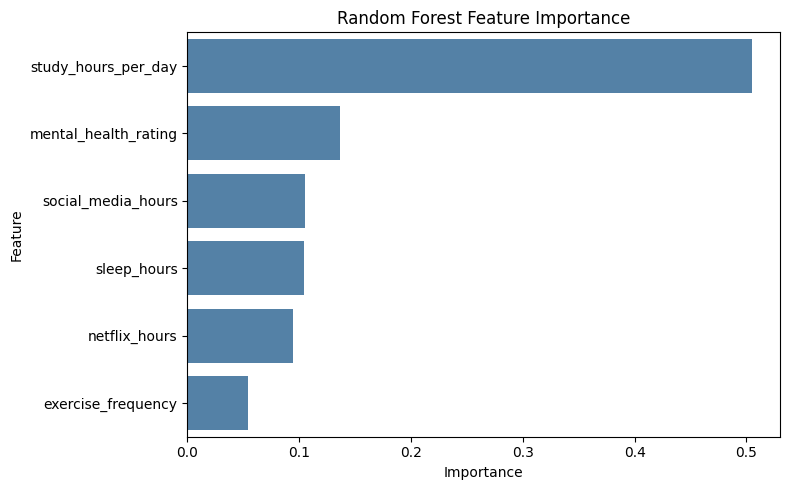

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100

print("=== Random Forest Classifier ===")
print(f"Accuracy: {accuracy_rf:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

importances = rf_model.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, color='steelblue')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Random Forest Classifier Results

The Random Forest model achieved an accuracy of **85.00%**, with balanced precision, recall, and F1-scores for both Pass and Fail categories. The confusion matrix shows the model misclassified 45 students, almost evenly split between false positives and false negatives.

The feature importance plot highlights `study_hours_per_day` as the most significant factor by a wide margin, followed by `mental_health_rating` and `social_media_hours`. These results reinforce earlier EDA findings, emphasizing the role of study habits and mental wellness in academic performance.


# K-Nearest Neighbors (KNN)

In [20]:
best_k = 0
best_accuracy = 0

print("=== Tuning K for KNN ===\n")
for k in [3, 5, 7, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"k = {k}: Accuracy = {acc:.2f}%")

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k

print(f"\nBest k value: {best_k} with Accuracy: {best_accuracy:.2f}%\n")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn) * 100

print("=== Final K-Nearest Neighbors (KNN) ===")
print(f"Accuracy: {accuracy_knn:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== Tuning K for KNN ===

k = 3: Accuracy = 82.33%
k = 5: Accuracy = 82.67%
k = 7: Accuracy = 82.00%
k = 10: Accuracy = 83.33%

Best k value: 10 with Accuracy: 83.33%

=== Final K-Nearest Neighbors (KNN) ===
Accuracy: 83.33%

Classification Report:
               precision    recall  f1-score   support

        Fail       0.81      0.86      0.83       147
        Pass       0.86      0.81      0.83       153

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300

Confusion Matrix:
 [[126  21]
 [ 29 124]]


### K-Nearest Neighbors (KNN) Classifier Results
Based on this comparison, the final model used `k = 10`, which achieved the highest accuracy of **83.33%** on the test set.

The classification report shows balanced performance across both classes.
The confusion matrix indicates that the model correctly predicted 126 Fail and 124 Pass cases, with 50 misclassifications (21 false positives, 29 false negatives). 

The KNN model strength lies in maintaining balance across both categories, making it a consistent and interpretable option for binary classification.


# Gaussian Naive Bayes

In [21]:
gnb_model = GaussianNB()

gnb_model.fit(X_train, y_train)

y_pred_gnb = gnb_model.predict(X_test)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb) * 100

print("=== Gaussian Naive Bayes (GNB) ===")
print(f"Accuracy: {accuracy_gnb:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_gnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gnb))

=== Gaussian Naive Bayes (GNB) ===
Accuracy: 85.00%

Classification Report:
               precision    recall  f1-score   support

        Fail       0.85      0.84      0.85       147
        Pass       0.85      0.86      0.85       153

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Confusion Matrix:
 [[124  23]
 [ 22 131]]


### Gaussian Naive Bayes (GNB) Classifier Results

The Gaussian Naive Bayes model achieved an accuracy of **85.00%**, matching the performance of the Random Forest model. Precision, recall, and F1-scores are balanced at 0.85 for both Pass and Fail categories, indicating consistent performance across both classes.

The confusion matrix shows that the model correctly predicted 124 Fail and 131 Pass outcomes, with 45 total misclassifications.


# Gradient Boosting

In [22]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb) * 100

print("=== Gradient Boosting Classifier ===")
print(f"Accuracy: {accuracy_gb:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

=== Gradient Boosting Classifier ===
Accuracy: 84.67%

Classification Report:
               precision    recall  f1-score   support

        Fail       0.84      0.84      0.84       147
        Pass       0.85      0.85      0.85       153

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Confusion Matrix:
 [[124  23]
 [ 23 130]]


### Gradient Boosting Classifier Results

The Gradient Boosting model achieved an accuracy of **84.67%**, showing strong and balanced performance across both Pass and Fail classifications. With precision, recall, and F1-scores all at or near 0.85, the model demonstrated reliable generalization without favoring one class over the other.

The confusion matrix reveals that the model correctly predicted 124 Fail and 130 Pass outcomes, with 46 misclassifications: nearly identical performance to the Gaussian Naive Bayes and Random Forest models. 


# AdaBoost

=== AdaBoost Classifier ===
Accuracy: 86.00%

Classification Report:
               precision    recall  f1-score   support

        Fail       0.87      0.84      0.86       147
        Pass       0.85      0.88      0.86       153

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

Confusion Matrix:
 [[124  23]
 [ 19 134]]


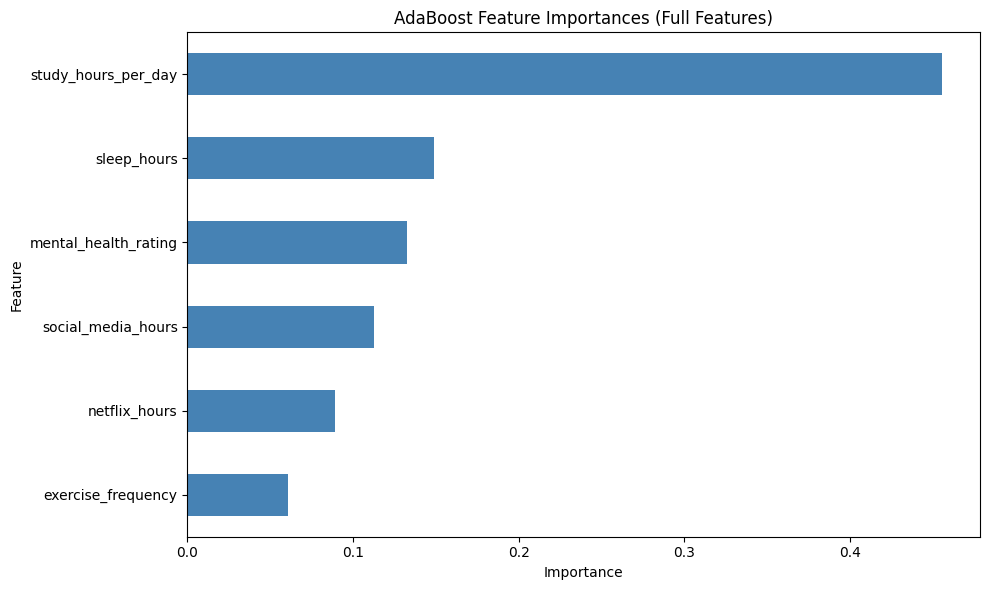

In [23]:
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

accuracy_ada = accuracy_score(y_test, y_pred_ada) * 100
print("=== AdaBoost Classifier ===")
print(f"Accuracy: {accuracy_ada:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

importances = ada_model.feature_importances_
feature_names = X_train.columns  # Make sure X_train is a DataFrame

feat_imp = pd.Series(importances, index=feature_names).sort_values()

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title("AdaBoost Feature Importances (Full Features)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### AdaBoost Classifier Results

The AdaBoost model achieved an accuracy of **86.00%**. It demonstrated strong and balanced precision and recall for both Pass and Fail classes, with an F1-score of 0.86 across the board.

The confusion matrix shows that the model correctly predicted 124 Fail and 134 Pass outcomes, with only 42 misclassifications: fewer than most other models tested. Notably, it had only 19 false negatives,indicating a strong ability to correctly identify students who actually passed.


# Voting Classifier

In [24]:
svc = SVC(probability=True, kernel='linear', random_state=42)
gnb = GaussianNB()
abc = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('svc', svc), ('gnb', gnb), ('abc', abc), ('rf', rf)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

y_pred_vote = voting_clf.predict(X_test)
accuracy_vote = accuracy_score(y_test, y_pred_vote) * 100

print("=== Voting Classifier ===")
print(f"Accuracy: {accuracy_vote:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_vote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vote))

=== Voting Classifier ===
Accuracy: 87.00%

Classification Report:
               precision    recall  f1-score   support

        Fail       0.88      0.86      0.87       147
        Pass       0.87      0.88      0.87       153

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

Confusion Matrix:
 [[126  21]
 [ 18 135]]


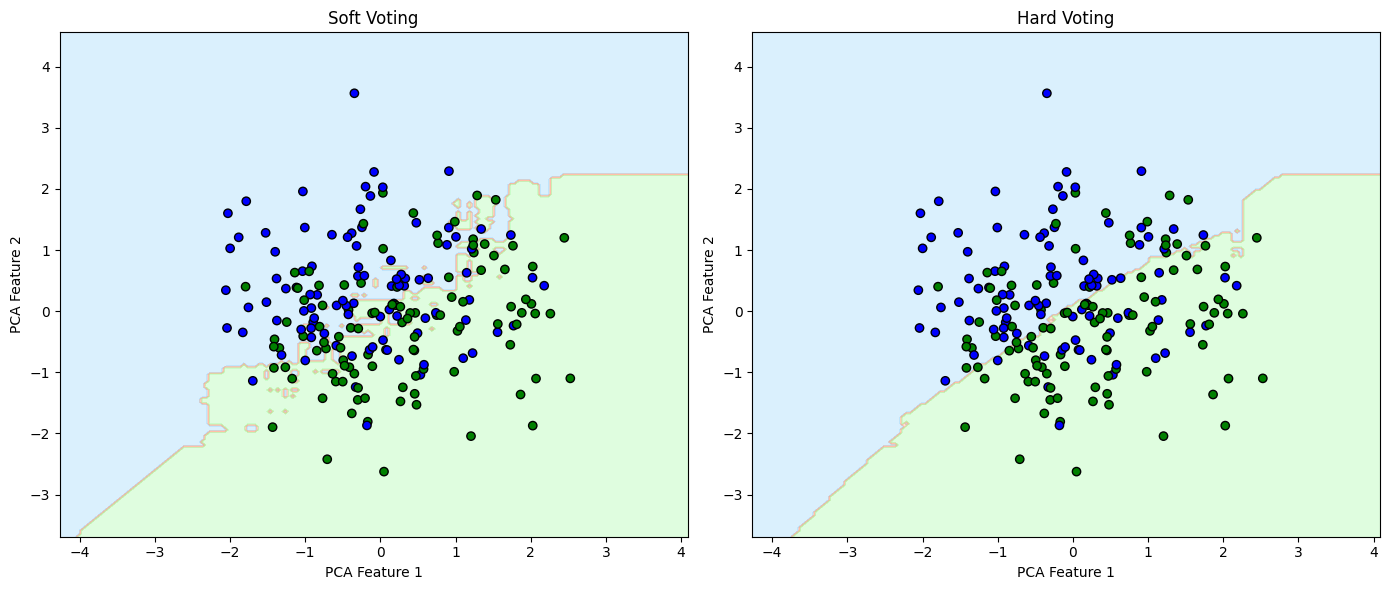

['Fail' 'Pass']


In [30]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y should be 'Pass'/'Fail' or similar

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_encoded, test_size=0.2, random_state=42
)

svc = SVC(probability=True, kernel='linear', random_state=42)
gnb = GaussianNB()  # No random_state needed
abc = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

voting_clf_soft = VotingClassifier(
    estimators=[('svc', svc), ('gnb', gnb), ('abc', abc), ('rf', rf)],
    voting='soft'
)

voting_clf_hard = VotingClassifier(
    estimators=[('svc', svc), ('gnb', gnb), ('abc', abc), ('rf', rf)],
    voting='hard'
)

voting_clf_soft.fit(X_train_pca, y_train_pca)
voting_clf_hard.fit(X_train_pca, y_train_pca)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_soft = voting_clf_soft.predict(grid).reshape(xx.shape)
Z_hard = voting_clf_hard.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].contourf(xx, yy, Z_soft, alpha=0.3, cmap=ListedColormap(['#87CEFA', '#FFA07A', '#98FB98']))
axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, edgecolor='k', cmap=ListedColormap(['#0000FF', '#FF4500', '#008000']))
axes[0].set_title("Soft Voting")
axes[0].set_xlabel("PCA Feature 1")
axes[0].set_ylabel("PCA Feature 2")

axes[1].contourf(xx, yy, Z_hard, alpha=0.3, cmap=ListedColormap(['#87CEFA', '#FFA07A', '#98FB98']))
axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, edgecolor='k', cmap=ListedColormap(['#0000FF', '#FF4500', '#008000']))
axes[1].set_title("Hard Voting")
axes[1].set_xlabel("PCA Feature 1")
axes[1].set_ylabel("PCA Feature 2")

plt.tight_layout()
plt.show()

print(y.unique())


### Voting Classifier Results

The Voting Classifier ensemble achieved an accuracy of **87.00%**, tying closely with the SVC. It combined the strengths of SVC, Gaussian Naive Bayes, AdaBoost, and Random Forest using soft voting, which averages the predicted probabilities of each model.

The confusion matrix indicates only **39 misclassifications** — the lowest overall — including just 18 false negatives and 21 false positives.

## Soft vs. Hard Voting Decision Boundaries

In both soft and hard voting classifiers, we observe a reasonably clear division between the two classes (e.g., Pass = green, Fail = blue). 

- **Soft Voting** uses class probabilities and results in a smoother, more responsive decision boundary that adapts to small shifts in the data. In this case, the soft voting model exhibits a more **flexible and intricate boundary**, especially around denser regions of overlap, indicating higher sensitivity to mixed or borderline examples.
  
- **Hard Voting**, based on majority vote, produces a **slightly simpler and more angular boundary**, potentially leading to more abrupt decisions but fewer fluctuations in uncertain regions.

- Despite these structural differences, both models yield **similar global patterns**, reinforcing that ensemble methods agree on the overall data structure. The variation in the boundaries highlights the trade-off between probability-driven flexibility (soft) and majority-rule consistency (hard).


# Model comparison

In [26]:
models = pd.DataFrame({
    'Model': [
        'Support Vector Machine (SVC)','K-Nearest Neighbors (KNN)','Random Forest','Gaussian Naive Bayes','Gradient Boosting','AdaBoost','Voting Classifier'],
    'Score': [
        accuracy_svc, accuracy_knn, accuracy_rf, accuracy_gnb, accuracy_gb, accuracy_ada, accuracy_vote]
})

models = models.sort_values(by='Score', ascending=False).reset_index(drop=True)
print(models)

                          Model      Score
0  Support Vector Machine (SVC)  87.666667
1             Voting Classifier  87.000000
2                      AdaBoost  86.000000
3          Gaussian Naive Bayes  85.000000
4                 Random Forest  85.000000
5             Gradient Boosting  84.666667
6     K-Nearest Neighbors (KNN)  83.333333


# Conclusion

The **Support Vector Machine (SVC)** achieved the highest accuracy at **87.67%**, making it the top individual performer in this analysis. However, the **Voting Classifier**, which combined predictions from SVC, Random Forest, AdaBoost, and Naive Bayes using soft voting, also delivered excellent results with **87.00% accuracy**. 

Given its balanced performance and ability to integrate multiple models, the Voting Classifier stands out as the **most reliable and robust overall solution**. Ensemble methods like AdaBoost and Gradient Boosting also ranked highly, reinforcing the strength of combining models to improve prediction quality.

- **Study Hours Per Day** was consistently ranked as the most important feature across tree-based models, confirming its critical role in academic success.
- The data shows a strong separation between pass and fail groups based on key habits, validating that academic performance can be meaningfully modeled using non-academic factors.